# 実践プロジェクト_ロジスティック回帰によるタイタニック号乗客の生存予測

## 分析目標

本データ分析レポートの目的は、タイタニック号の乗客の性別や客室等級などの属性に基づいて生存状況のロジスティック回帰分析を行い、構築したモデルを用いて、生存状況が不明な乗客について、その属性から沈没事故で生存したかどうかを予測することである。


## 概要

データセットには、`titianic_train.csv`と`titanic_test.csv`の2つのデータ表が含まれている。

`titianic_train.csv`には、800人を超えるタイタニック号の乗客について、沈没事故後の生存状況と、客室等級、性別、年齢、同乗していた配偶者・兄弟姉妹の人数、同乗していた親・子どもの人数などの関連情報が記録されている。

`titanic_test.csv`には、乗客（これらの乗客は`titianic_train.csv`には含まれていない）の関連情報のみが含まれており、このファイルは乗客が生存したかどうかを予測するために使用できる。


`titianic_train.csv`の各列の意味は以下のとおり：

* PassengerId：乗客ID
* survival：生存したか

  * 0	いいえ
  * 1	はい
* pclass：客室等級

  * 1	1等客室
  * 2	2等客室
  * 3  3等客室
* sex：性別
* Age：年齢
* sibsp：同乗していた配偶者・兄弟姉妹の人数
* parch：同乗していた親・子どもの人数
* ticket：乗船券番号
* fare：運賃
* cabin：客室番号
* embarked：乗船港

  * C  シェルブール

  * Q  クイーンズタウン

  * S  サウサンプトン

`titianic_test.csv`の各列の意味は上記と同じだが、survival変数、つまり生存したかどうかのデータは含まれていない。

## データの読み込み

In [455]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

まず`titanic_train.csv`を使用して予測モデルを学習する予定であるため、データの読み込みでは、現時点では`titanic_train.csv`のみをインポートする。

Pandasの`read_csv`関数を使用して、元のデータファイル`titanic_train.csv`のデータ内容をDataFrameとして読み込み、変数`original_titanic_train`に代入する。


In [456]:
original_titanic_train = pd.read_csv("titanic_train.csv")
original_titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## データの評価とクリーニング

この部分では、前の部分で作成した`original_titanic_train`DataFrameに含まれるデータを評価し、クリーニングする。

主に構造と内容、つまり整然性と清潔性の2つの側面から行う。

データの構造上の問題とは、「各変数が1列、各観測値が1行、各種類の観測単位が1つの表」という3つの基準を満たしていないことを指す。データの内容上の問題には、欠損データ、重複データ、無効なデータなどが含まれる。
クリーニング済みのデータと元のデータを区別するため、新しい変数`cleaned_titanic_train`を作成し、`original_titanic_train`をコピーしたものとする。以降のクリーニング処理はすべて`cleaned_titanic_train`に適用する。


In [457]:
cleaned_titanic_train = original_titanic_train.copy()

### データの整然性

In [458]:
cleaned_titanic_train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


先頭の10行のデータを見ると、データは以下の原則を満たしている。

各変数が1つの列を構成している

各観測値が1つの行を構成している

各種類の観測単位が1つの表を構成している

したがって、構造上の問題は存在しない。

### データの清潔性

In [459]:
cleaned_titanic_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


出力結果を見ると、`cleaned_titanic_train`には891件の観測値があり、`Age`、`Cabin`、`Embarked`には欠損値が存在する。これらについては、後続の処理で評価とクリーニングを行う。

データ型について、`PassengerId`は乗客IDを表しているため、数値型ではなく文字列型とする必要がある。したがって、データ型を変換する。

また、`Survived`（生存の有無）、`Pclass`（客室等級）、`Sex`（性別）、`Embarked`（乗船港）は分類データであるため、すべて`category`型に変換できる。


In [460]:
cleaned_titanic_train["PassengerId"] = cleaned_titanic_train["PassengerId"].astype("str")

In [461]:
cleaned_titanic_train["Survived"] = cleaned_titanic_train["Survived"].astype("category")
cleaned_titanic_train['Pclass'] = cleaned_titanic_train['Pclass'].astype('category')
cleaned_titanic_train['Sex'] = cleaned_titanic_train['Sex'].astype('category')
cleaned_titanic_train['Embarked'] = cleaned_titanic_train['Embarked'].astype('category')

In [462]:
cleaned_titanic_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    str     
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    str     
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    str     
 11  Embarked     889 non-null    category
dtypes: category(4), float64(2), int64(2), str(4)
memory usage: 59.4 KB


#### 欠損データの処理

infoメソッドの出力結果を見ると、cleaned_titanic_trainでは、Age、Cabin、Embarkedの各変数に欠損値が存在する。

年齢変数には177件の欠損値があり、データ全体の約20％を占めている。これらの観測値は数が多く、ほかの変数も分析に有用な情報を提供できるため、該当する行は削除せずに残す。

ただし、後で使用するロジスティック回帰関数`Logit`では、データに欠損値が含まれていることが許容されない。そのため、年齢の欠損値を乗客の平均年齢で補完する。


In [463]:
average_age = cleaned_titanic_train['Age'].mean()
cleaned_titanic_train['Age'] = cleaned_titanic_train['Age'].fillna(average_age)
cleaned_titanic_train['Age'].isna().sum()

np.int64(0)

In [464]:
cleaned_titanic_train[cleaned_titanic_train['Cabin'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.000000,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.000000,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S


船室番号の変数には687件の欠損値がある。これは、大部分の観測値で船室番号が不明であることを示しているため、これらの観測値を削除することはできない。

また、船室番号は生存確率に影響を与える主要な要因ではないと考え、ロジスティック回帰の説明変数には含めない。そのため、船室番号に欠損値があってもモデルの構築には影響せず、これらの観測値はそのまま保持できる。


In [465]:
cleaned_titanic_train[cleaned_titanic_train['Embarked'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


乗船港の変数に欠損値がある観測値は2件のみである。ただし、乗船港は生存確率に影響を与える主要な要因ではないと考え、ロジスティック回帰の説明変数には含めない。

そのため、乗船港に欠損値があってもモデルの構築には影響せず、これらの観測値はそのまま保持できる。


#### 重複データの処理

データの各変数の意味と内容から、`PassengerId`は乗客を一意に識別するための識別子であり、重複してはならない。そのため、重複値が存在するかを確認する。


In [466]:
cleaned_titanic_train["PassengerId"].duplicated().sum()

np.int64(0)

出力結果は0であり、重複値が存在しないことを示している。


#### 不整合データの処理

不整合データはすべてのカテゴリ変数に存在する可能性があるため、異なる値が実際には同じ対象を示しているケースがないかを確認する。


In [467]:
cleaned_titanic_train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [468]:
cleaned_titanic_train["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [469]:
cleaned_titanic_train["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [470]:
cleaned_titanic_train["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

以上の出力結果から、いずれの変数にも不整合なデータは存在しない。

#### 無効または誤ったデータの処理

DataFrameのdescribeメソッドを使用すると、数値データの統計情報を素早く把握できる。

In [471]:
cleaned_titanic_train.describe()

,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,13.002015,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,7.910400
50%,29.699118,0.000000,0.000000,14.454200
75%,35.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


乗客の平均年齢は約30歳で、最高年齢は80歳、最低年齢は0.42歳である。同乗している配偶者・兄弟姉妹の人数は最大8人、最小0人である。同乗している親・子供の人数は最大6人、最小0人である。乗船料金の平均は約32で、最大値は512、最小値は0である。料金が0の場合は、招待券などの無料乗船を示していると推測される。データには、現実的にあり得ない数値は存在しない。

## データの整理

データの整理は、分析の方向性と密接に関係している。今回のデータ分析の目的は、タイタニック号の乗客に関する情報を基に、沈没事故発生後の生存確率を予測することである。

データには、同乗している配偶者・兄弟姉妹の人数と、同乗している親・子供の人数が含まれている。これらを利用すれば、船内にいる家族の人数を算出できる。同乗家族の人数が生存に有意な影響を与えるかに関心があるため、この人数を記録する新しい変数を作成する。


In [472]:
cleaned_titanic_train['FamilyNum'] = cleaned_titanic_train['SibSp'] + cleaned_titanic_train['Parch']
cleaned_titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyNum
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


## データの探索

ロジスティック回帰分析に着手する前に、まずデータ可視化を用いて数値変数の分布や、乗客の生存の有無と関連する可能性のある変数を探索し、その後の詳細な分析の方向性を明確にする。


In [473]:
# 设置图表色盘为"pastel"
sns.set_palette("pastel")

In [474]:
# 设置图表尺寸
plt.rcParams["figure.figsize"] = [7.00, 3.50]
plt.rcParams["figure.autolayout"] = True

### 生存者の割合

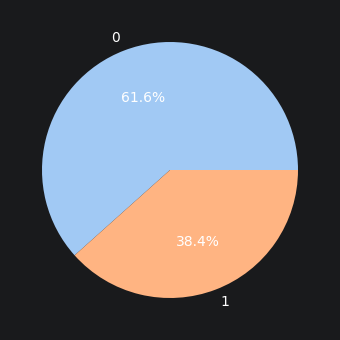

In [475]:
survived_count = cleaned_titanic_train['Survived'].value_counts()
survived_label = survived_count.index
plt.pie(survived_count, labels=survived_label, autopct='%.1f%%')
plt.show()

上の円グラフから、タイタニック号では死亡した乗客のほうが生存した乗客より多く、その比率はおよそ3：2であることが分かる。


### 乗客の年齢

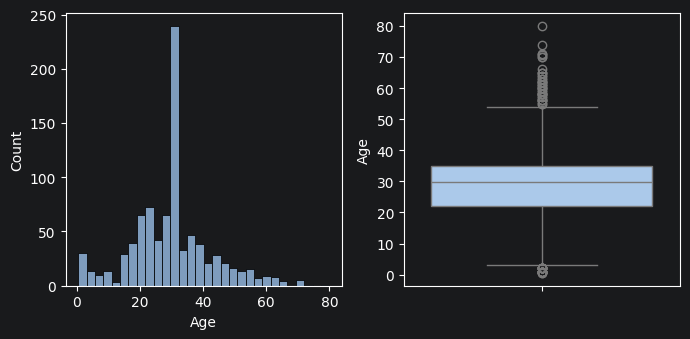

In [476]:
figure, axes = plt.subplots(1, 2)
sns.histplot(cleaned_titanic_train, x='Age', ax=axes[0])
sns.boxplot(cleaned_titanic_train, y='Age', ax=axes[1])
plt.show()

乗客の多くは20歳から40歳までの年齢層に集中しているが、高齢者や乳幼児も少なくない。


### 乗客の年齢と生存の有無

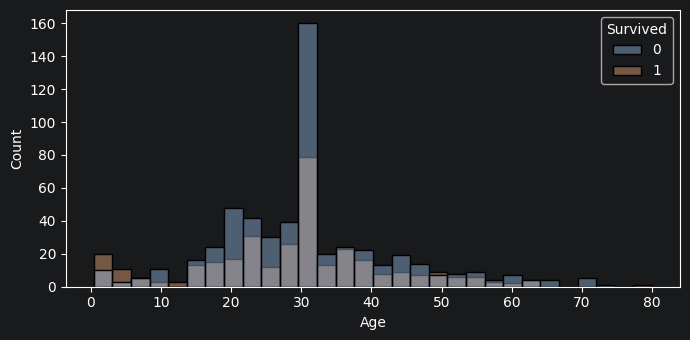

In [477]:
sns.histplot(cleaned_titanic_train, x='Age', hue='Survived', alpha=0.4)
plt.show()

乗客年齢のヒストグラムから、乳幼児の年齢層だけは生存者の割合が高いが、それ以外のほとんどの年齢層では、生存者数より死亡者数のほうが多いことが分かる。


### 乗船料金の分布

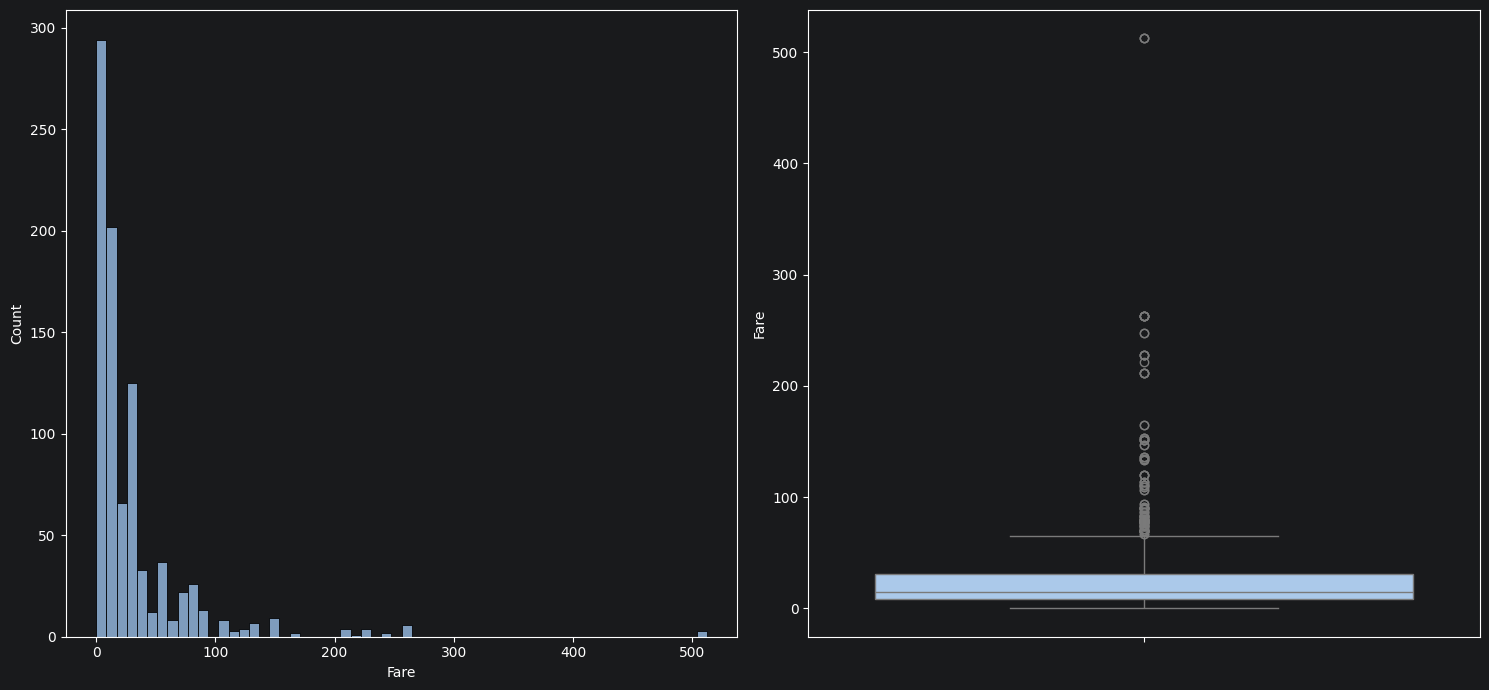

In [478]:
figure, axes = plt.subplots(1, 2, figsize=[15, 7])
sns.histplot(cleaned_titanic_train, x='Fare', ax=axes[0])
sns.boxplot(cleaned_titanic_train, y='Fare', ax=axes[1])
plt.show()

乗船料金は右に裾の長い分布を示している。これは、データセット内の乗船料金の多くが中程度である一方、非常に高額な料金が外れ値として存在し、平均値を押し上げていることを示している。


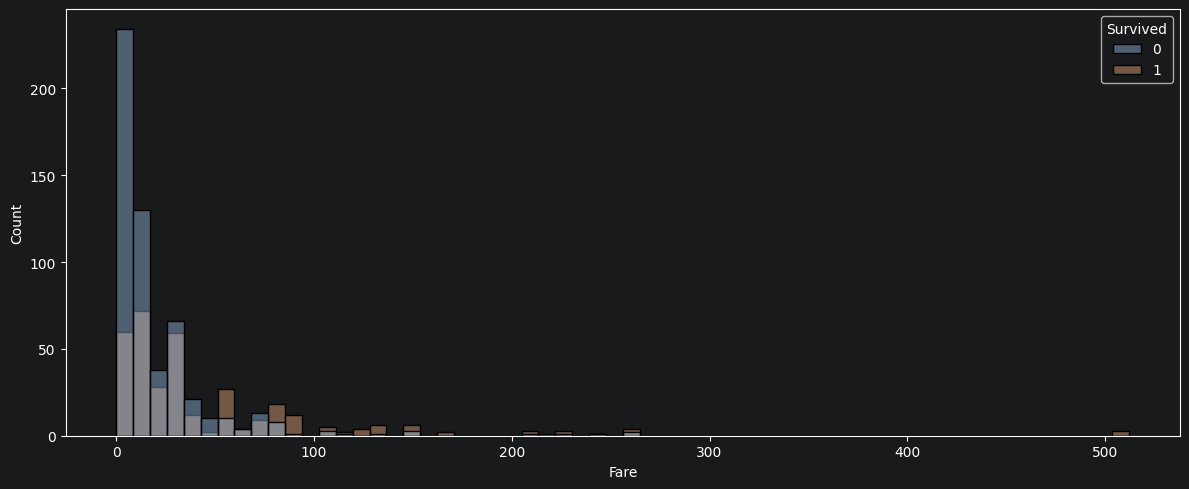

In [479]:
plt.subplots(1, 1, figsize=[12, 5])
sns.histplot(cleaned_titanic_train, x='Fare', hue='Survived', alpha=0.4)
plt.show()

### 客室等級と生存の有無の関係

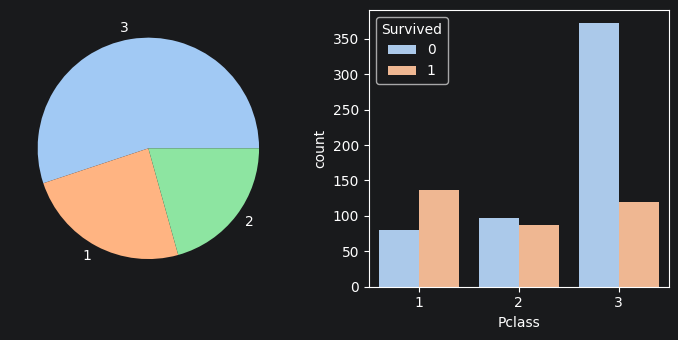

In [480]:
figure, axes = plt.subplots(1, 2)
pclass_count = cleaned_titanic_train['Pclass'].value_counts()
pclass_label = pclass_count.index
axes[0].pie(pclass_count, labels=pclass_label)
sns.countplot(cleaned_titanic_train, x='Pclass', hue='Survived', ax=axes[1])
plt.show()

生存の有無と客室等級の関係を示す棒グラフから、客室等級が低い乗客ほど死亡者の割合が高く、客室等級が高い乗客ほど生存者の割合が高いことが分かる。


### 性別と生存の有無の関係

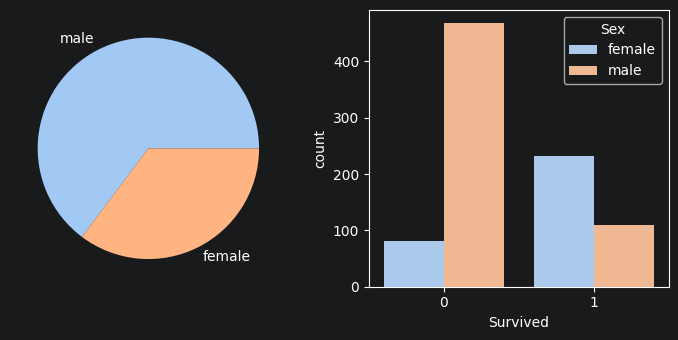

In [481]:
figure, axes = plt.subplots(1, 2)
sex_count = cleaned_titanic_train['Sex'].value_counts()
sex_label = sex_count.index
axes[0].pie(sex_count, labels=sex_label)
sns.countplot(cleaned_titanic_train, x='Survived', hue='Sex', ax=axes[1])
plt.show()

生存の有無と性別の関係を示す棒グラフから、男性乗客では死亡者の割合が高く、女性乗客では生存者の割合が高いことが分かる。


### 乗船港と生存の有無の関係

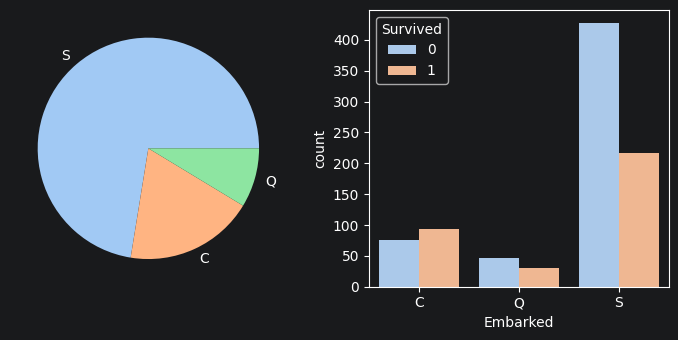

In [482]:
figure, axes = plt.subplots(1, 2)
embarked_count = cleaned_titanic_train['Embarked'].value_counts()
embarked_label = embarked_count.index
axes[0].pie(embarked_count, labels=embarked_label)
sns.countplot(cleaned_titanic_train, x='Embarked', hue='Survived', ax=axes[1])
plt.show()

生存の有無と乗船港の関係を示す棒グラフから、シェルブールから乗船した乗客では生存者数が死亡者数を上回っている一方、クイーンズタウンとサウサンプトンでは死亡者数が生存者数を上回っていることが分かる。


### 家族人数と生存の有無の関係

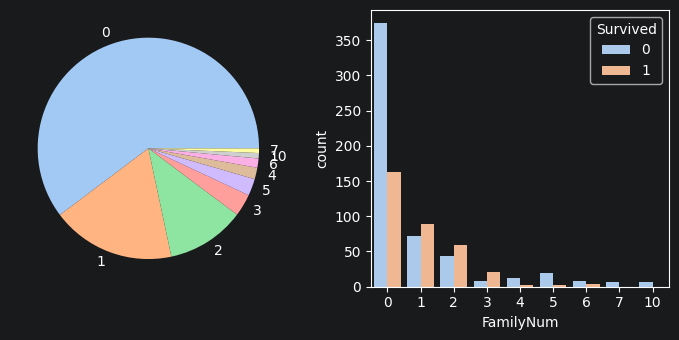

In [483]:
figure, axes = plt.subplots(1, 2)
familyNum_count = cleaned_titanic_train['FamilyNum'].value_counts()
familyNum_label = familyNum_count.index
axes[0].pie(familyNum_count, labels=familyNum_label)
sns.countplot(cleaned_titanic_train, x='FamilyNum', hue='Survived', ax=axes[1])
plt.show()

生存の有無と同乗家族の人数の関係を示す棒グラフから、一人で乗船した乗客では生存者数より死亡者数のほうが多いことが分かる。家族と同乗した乗客では、同乗家族が1～3人の場合は生存者数が死亡者数を上回っているが、3人を超えると死亡者数のほうが多くなる。


In [484]:
cleaned_titanic_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    str     
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    str     
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    str     
 11  Embarked     889 non-null    category
 12  FamilyNum    891 non-null    int64   
dtypes: category(4), float64(2), int64(3), str(4)
memory usage: 66.8 KB


## データの分析

分析段階では、これまでにクリーニングしたデータを用いてロジスティック回帰分析を行う。目的は、タイタニック号の乗客が持つ各属性に基づき、沈没事故後に生存したかどうかを予測できる数理モデルを構築することである。

まず、ロジスティック回帰に必要なモジュールをインポートする。

次に、新しいDataFrameである`lr_titanic_train`を作成し、ロジスティック回帰分析に使用するデータとして扱う。

`cleaned_titanic_train`と分ける理由は、回帰分析を行う前に、ダミー変数の導入などのデータ準備が必要になる可能性があり、それらの処理を`lr_titanic_train`上で実行できるようにするためである。


In [485]:
import statsmodels.api as sm

In [486]:
lr_titanic_train = cleaned_titanic_train.copy()
lr_titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyNum
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


乗客の生存確率に影響を与える可能性が低い変数を削除する。


In [487]:
lr_titanic_train = lr_titanic_train.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked'], axis=1)
lr_titanic_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilyNum
0,0,3,male,22.0,1,0,7.2500,1
1,1,1,female,38.0,1,0,71.2833,1
2,1,3,female,26.0,0,0,7.9250,0
3,1,1,female,35.0,1,0,53.1000,1
4,0,3,male,35.0,0,0,8.0500,0


データにはカテゴリ変数が含まれているため、そのままではロジスティック回帰モデルを構築できない。そこで、各カテゴリに該当するかどうかを0と1で表すダミー変数を導入する必要がある。


In [488]:
lr_titanic_train = pd.get_dummies(lr_titanic_train, drop_first=True, columns=['Pclass', 'Sex'], dtype=int)
lr_titanic_train.head()

,Survived,Age,SibSp,Parch,Fare,FamilyNum,Pclass_2,Pclass_3,Sex_male
0,0,22.0,1,0,7.2500,1,0,1,1
1,1,38.0,1,0,71.2833,1,0,0,0
2,1,26.0,0,0,7.9250,0,0,1,0
3,1,35.0,1,0,53.1000,1,0,0,0
4,0,35.0,0,0,8.0500,0,0,1,1


次に、目的変数と説明変数を分ける。

目的変数は`Survived`変数である。ロジスティック回帰の目的は、乗客の生存確率に影響を与える可能性があるその他の変数に基づき、生存の有無を予測することだからである。


In [489]:
y = lr_titanic_train["Survived"]

`Survived`以外の変数をまず説明変数に含めることができるが、変数間の相関を確認する必要がある。変数同士の相関が高い場合、多重共線性が生じる可能性がある。


In [490]:
X = lr_titanic_train.drop(["Survived"], axis=1)

In [491]:
X.corr().abs() > 0.8

,Age,SibSp,Parch,Fare,FamilyNum,Pclass_2,Pclass_3,Sex_male
Age,True,False,False,False,False,False,False,False
SibSp,False,True,False,False,True,False,False,False
Parch,False,False,True,False,False,False,False,False
Fare,False,False,False,True,False,False,False,False
FamilyNum,False,True,False,False,True,False,False,False
Pclass_2,False,False,False,False,False,True,False,False
Pclass_3,False,False,False,False,False,False,True,False
Sex_male,False,False,False,False,False,False,False,True


<Axes: >

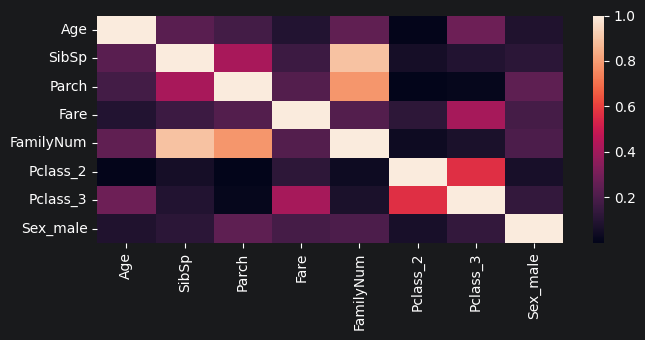

In [492]:
sns.heatmap(X.corr().abs(), annot=False, fmt=".2g", cmap=None)

上記の出力から、`SibSp`と`FamilyNum`の相関係数の絶対値が0.8を上回っていることがわかる。これは予想どおりであり、`FamilyNum`は`SibSp`と`Parch`をもとに計算された変数だからである。

異なる変数間の相関が高すぎると、数値最適化アルゴリズムが収束せず、ロジスティック回帰モデルのパラメータを計算できない可能性がある。そのため、`FamilyNum`または`SibSp`のどちらかを削除する必要がある。同乗している家族の人数が生存確率に影響するかどうかに関心があるため、ここでは`FamilyNum`を残す。

さらに、相関係数を詳しく見ると、`Parch`と`FamilyNum`の間にも強い相関があり、相関係数は0.78で、0.8に近いことがわかる。そのため、アルゴリズムが収束しない問題を避けるために、`Parch`も削除する。


In [493]:
X = X.drop(['Parch', 'SibSp'], axis=1)

次に、モデルの線形方程式に切片を追加する。


In [494]:
X = sm.add_constant(X)

次に、`Logit`関数を呼び出し、最尤法による最適化を用いてロジスティック回帰モデルのパラメータを推定し、サマリー情報を出力する。


In [495]:
model = sm.Logit(y, X).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.443547
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      884
Method:                           MLE   Df Model:                            6
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                  0.3339
Time:                        17:15:36   Log-Likelihood:                -395.20
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 1.786e-82
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8097      0.445      8.568      0.000       2.938       4.681
Age           -0.0388      0.008     -4.963      0.000      -0.054      -0.023
Fare           0.0032      0.002      1.311      0.190      -0.002       0.008
FamilyNum     -0.2430      0.068     -3.594      0.000      -0.376      -0.110
Pclass_2      -1.0003      0.293     -3.416      0.001      -1.574      -0.426
Pclass_3      -2.1324      0.289     -7.373      0.000      -2.699      -1.566
Sex_male      -2.7759      0.199    -13.980      0.000      -3.165      -2.387
==============================================================================
"""

有意水準を0.05に設定した場合、上記の結果におけるP値から、モデルは運賃が乗客の生存確率に有意な影響を与えていないと判断していることがわかる。そのため、この変数を削除したうえで、ロジスティック回帰モデルを再構築する。


In [496]:
X = X.drop(['Fare'], axis=1)
model = sm.Logit(y, X).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.444623
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      885
Method:                           MLE   Df Model:                            5
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                  0.3323
Time:                        17:15:36   Log-Likelihood:                -396.16
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 4.927e-83
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0620      0.404     10.049      0.000       3.270       4.854
Age           -0.0395      0.008     -5.065      0.000      -0.055      -0.024
FamilyNum     -0.2186      0.065     -3.383      0.001      -0.345      -0.092
Pclass_2      -1.1798      0.261     -4.518      0.000      -1.692      -0.668
Pclass_3      -2.3458      0.242     -9.676      0.000      -2.821      -1.871
Sex_male      -2.7854      0.198    -14.069      0.000      -3.173      -2.397
==============================================================================
"""

ロジスティック回帰モデルは、次の要因の増加または該当が生存確率を低下させると予測している。

* 年齢が高い
* 同乗している家族の人数が多い
* 1等客室ではない
* 性別が男性である

各説明変数の係数が実際に何を意味するのかを理解するには、自然定数を底として係数を指数化する必要がある。


In [497]:
# Age
np.exp(-0.0395)

np.float64(0.9612699539905982)

In [498]:
# FamilyNum
np.exp(-0.2186)

np.float64(0.803643111115195)

In [499]:
# Pclass_2
np.exp(-1.1798)

np.float64(0.30734020049483596)

In [500]:
# Pclass_3
np.exp(-2.3458)

np.float64(0.09577055503172162)

In [501]:
# Sex_male
np.exp(-2.7854)

np.float64(0.061704402333015156)

以上の結果は、次のことを示している。

年齢が1歳上がるごとに、生存オッズは約4％低下する。
同乗している家族が1人増えるごとに、生存オッズは約20％低下する。
2等客室の乗客の生存オッズは、1等客室の乗客より約71％低い。
3等客室の乗客の生存オッズは、1等客室の乗客より約90％低い。
男性乗客の生存オッズは、女性乗客より約94％低い。

モデルのパラメータ値から、次のようにまとめられる。

年齢が低い乗客ほど生存確率が高い。
女性乗客は、男性乗客より生存確率が高い。
客室等級が高い乗客ほど生存確率が高い。
同乗している家族の人数が少ない乗客ほど生存確率が高い。

最初の2点の背景には、タイタニック号の沈没後に避難する際の「子どもと女性を先に避難させる」という原則が関係していた可能性がある。

3点目は、当時、より上位の客室等級の乗客が優先的に避難できた可能性を示している。

4点目は、家族の人数が多い乗客ほど、災害発生時に自分の避難よりも他の家族を助けることを優先し、その結果、自分自身が避難する機会も失った可能性がある。

モデルを構築した後、`titianic_test.csv`に含まれるタイタニック号の乗客の生存状況を予測する。

まず、`titianic_test.csv`のデータを読み込む。


In [502]:
titanic_test = pd.read_csv("titanic_test.csv")
titanic_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


ロジスティック回帰モデルでは欠損値を含むデータを使用できないため、`titanic_test`に欠損値が存在するかを確認する必要がある。


In [503]:
titanic_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


上記の出力から、`Age`、`Fare`、`Cabin`に欠損値が存在することがわかる。

このうち、`Fare`と`Cabin`は回帰モデルの説明変数ではないため、欠損値があっても予測には影響しない。そのため、これらの欠損値は無視できる。

一方、`Age`については、`cleaned_titanic_train`に対して行った処理と同様に、平均値で欠損値を補完する必要がある。


In [504]:
titanic_test['Age'] = titanic_test['Age'].fillna(titanic_test['Age'].mean())
titanic_test['Age'].isna().sum()

np.int64(0)

上記の出力から、`Age`、`Fare`、`Cabin`に欠損値が存在することがわかる。

このうち、`Fare`と`Cabin`は回帰モデルの説明変数ではないため、欠損値があっても予測には影響しない。そのため、これらの欠損値は無視できる。

一方、`Age`については、`cleaned_titanic_train`に対して行った処理と同様に、平均値で欠損値を補完する必要がある。


In [505]:
titanic_test['Pclass'] = pd.Categorical(titanic_test['Pclass'], categories=[1, 2, 3])
titanic_test['Sex'] = pd.Categorical(titanic_test['Sex'], categories=['female', 'male'])
titanic_test['Embarked'] = pd.Categorical(titanic_test['Embarked'], categories=['C', 'Q', 'S'])

次に、モデルで使用するカテゴリ変数にダミー変数を導入する。

In [506]:
titanic_test = pd.get_dummies(titanic_test, drop_first=True, columns=['Pclass', 'Sex'], dtype=int)
titanic_test.head()

,PassengerId,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_2,Pclass_3,Sex_male
0,892,"Kelly, Mr. James",34.5,0,0,330911,7.8292,NaN,Q,0,1,1
1,893,"Wilkes, Mrs. James (Ellen Needs)",47.0,1,0,363272,7.0000,NaN,S,0,1,0
2,894,"Myles, Mr. Thomas Francis",62.0,0,0,240276,9.6875,NaN,Q,1,0,1
3,895,"Wirz, Mr. Albert",27.0,0,0,315154,8.6625,NaN,S,0,1,1
4,896,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.0,1,1,3101298,12.2875,NaN,S,0,1,0


モデルが必要とする入力変数を確認する。

In [507]:
model.params

const        4.061982
Age         -0.039495
FamilyNum   -0.218627
Pclass_2    -1.179763
Pclass_3    -2.345823
Sex_male    -2.785398
dtype: float64

データ整理の段階でFamilyNum変数を作成したため、予測データにも同じ変数を追加する必要がある。

In [508]:
titanic_test['FamilyNum'] = titanic_test['SibSp'] + titanic_test['Parch']
titanic_test.head()

,PassengerId,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_2,Pclass_3,Sex_male,FamilyNum
0,892,"Kelly, Mr. James",34.5,0,0,330911,7.8292,NaN,Q,0,1,1,0
1,893,"Wilkes, Mrs. James (Ellen Needs)",47.0,1,0,363272,7.0000,NaN,S,0,1,0,1
2,894,"Myles, Mr. Thomas Francis",62.0,0,0,240276,9.6875,NaN,Q,1,0,1,0
3,895,"Wirz, Mr. Albert",27.0,0,0,315154,8.6625,NaN,S,0,1,1,0
4,896,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.0,1,1,3101298,12.2875,NaN,S,0,1,0,2


続いて、モデルに入力して予測を行うための変数を作成する。これらの変数は、モデルの学習時に使用した入力変数と一致させる必要がある。

In [509]:
X_test = titanic_test[['Age', 'FamilyNum', 'Pclass_2', 'Pclass_3', 'Sex_male']]
X_test = sm.add_constant(X_test)

これで、ロジスティック回帰モデルのpredictメソッドを呼び出し、予測された生存確率を取得できる。

In [510]:
predicted_value = model.predict(X_test)
predicted_value

0      0.080778
1      0.411265
2      0.086917
3      0.105684
4      0.601091
         ...   
413    0.094075
414    0.925647
415    0.069798
416    0.094075
417    0.062849
Length: 418, dtype: float64

ロジスティック回帰モデルによって、titanic_test.csvに含まれるタイタニック号の乗客の生存確率が予測された。

生存確率が0.5以上の場合は生存、0.5未満の場合は死亡と判定し、最終的な予測結果を出力する。

In [511]:
predicted_value > 0.5

0      False
1      False
2      False
3      False
4       True
       ...  
413    False
414     True
415    False
416    False
417    False
Length: 418, dtype: bool